In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from sdm_eurec4a.visulization import set_custom_rcParams

In [2]:
set_custom_rcParams()

['#CC6677', '#6E9CB3', '#CA8727', '#44AA99', '#AA4499', '#D6BE49', '#A494F5']

construct a time dimension with non equally spaced distances and for multiple days

In [219]:
# Generate non-equally spaced time deltas
time_deltas = np.random.choice([np.timedelta64(1, 's'), np.timedelta64(10, 's')], size=10)


time_deltas = np.array((
    np.timedelta64(1, 's'),
    np.timedelta64(1, 's'),
    np.timedelta64(1, 's'),
    np.timedelta64(4, 's'),
    np.timedelta64(1, 's'),
    np.timedelta64(1, 's'),
    np.timedelta64(1, 's'),
    np.timedelta64(1, 's'),
    np.timedelta64(1, 's'),
    np.timedelta64(1, 's'),
    np.timedelta64(1, 's'),
    np.timedelta64(4, 's'),
    np.timedelta64(1, 's'),
    np.timedelta64(1, 's'),
    np.timedelta64(1, 's'),
    np.timedelta64(4, 's'),
    np.timedelta64(1, 's'),
    np.timedelta64(1, 's'),
    np.timedelta64(1, 's'),
    np.timedelta64(1, 's'),
    np.timedelta64(1, 's'),
    np.timedelta64(1, 's'),
    np.timedelta64(1, 's'),

))

mask = np.array((
    True,
    True,
    True,
    False,
    False,
    True,
    True,
    False,
    True,
    True,
    False,
    False,
    True,
    True,
    True,
    True,
    True,
    True,
    False,
    True,
    True,
    True,
    True,
))

# Create the time dimension
time = np.datetime64('2023-01-01') + np.cumsum(time_deltas)

# Create a boolean mask
# Create the xarray DataArray
dataset = xr.Dataset()
data_array = xr.DataArray(mask, coords=[time], dims=["time"])
time_deltas = xr.DataArray(time_deltas, coords=[time], dims=["time"])
dataset['mask'] = data_array
dataset['time_deltas'] = time_deltas
dataset['time_deltas'] = dataset['time_deltas'].dt.seconds


In [335]:
import numpy as np
import xarray as xr

N = 2300
# Generate non-equally spaced time deltas
time_deltas = np.random.choice([1,1,1,1,1,1,1,1,4,4,4, 4, 10], size=N)  # Random integers between 1 and 10, array length 23
time_deltas = np.array([np.timedelta64(td, 's') for td in time_deltas])

mask = np.random.choice([True, True, False], size=N)

# Create the time dimension
time = np.datetime64('2023-01-01') + np.cumsum(time_deltas)

# Create the xarray DataArray
dataset = xr.Dataset()
data_array = xr.DataArray(mask, coords=[time], dims=["time"])
time_deltas = xr.DataArray(time_deltas, coords=[time], dims=["time"])
dataset['mask'] = data_array
dataset['time_deltas'] = time_deltas
dataset['time_deltas'] = dataset['time_deltas'].dt.seconds

print(dataset)

<xarray.Dataset>
Dimensions:      (time: 2300)
Coordinates:
  * time         (time) datetime64[ns] 2023-01-01T00:00:01 ... 2023-01-01T01:...
Data variables:
    mask         (time) bool False False False True ... True True False True
    time_deltas  (time) int64 1 1 4 1 1 1 4 10 1 4 1 4 ... 1 4 1 1 1 4 1 1 1 4 4


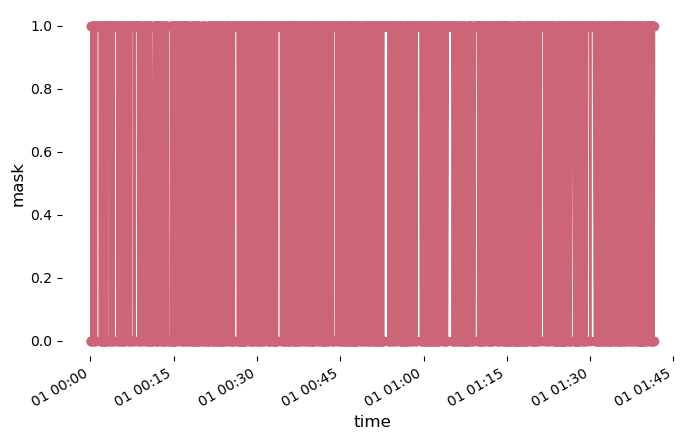

In [336]:
# dataset['time_deltas'].plot(marker = 'o')	
dataset['mask'].plot(marker = 'o')	

In [279]:

# da_mask: xr.DataArray = dataset['time_deltas']	
# max_itteration: int = 10
# min_duration: int = 3
# axis: str = "time"# make sure that the mask is boolean


def consecutive_events_xr(
    da_mask: xr.DataArray,
    min_duration: int = 1,
    axis: str = "time",
) -> xr.DataArray:
    """
    This function calculates the mask of consecutive events with a duration of at least
    ´´min_duration´´(default 1) It runs full on xarray and numpy.

    Parameters
    ----------
    da_mask : xr.DataArray
        boolean array as xarray dataarray.
    min_duration : int, optional
        how many consecutive events the mask needs to be True, by default 1.
        Default results in a mask similar to da_mask.
    axis : str, optional
        Specifies along which axis the consecutive events shall be calculated, by default 'time'.

    Returns
    -------
        xr.DataArray
            mask array with True for each timestep that is part of a consecutive event


    Notes
    --------------------------
    (1 - True, 0 - False)

    Example setup
        >>> da_mask = [1,0,1,1,1,0,0,1,1,1,1,0]
        >>> consecutive_events(da_mask, min_duration = 3)

    First for loop: mask_temporary
        >>> # It will create the following temporary mask_index (start index always moved to the right.)
        >>> [1,0,1,1,1,0,0,1,1,1]    # [1,0,1,1,1,0,0,1,1,1]
        >>> [0,1,1,1,0,0,1,1,1,1]    #   [0,1,1,1,0,0,1,1,1,1]
        >>> [1,1,1,0,0,1,1,1,1,0]    #     [1,1,1,0,0,1,1,1,1,0]
        >>>  - - - - - - - - - -     # with & operator the following will be done:
        >>> [0,0,1,0,0,0,0,1,1,0]    # <- mask_temporary:

    Second for loop:
        >>> # Here the ``mask_temporary`` will be moved to the right for each itteration.
        >>> # The ``+`` opertaor will be used (1+1=1, 1+0=1 , 0+0=0).
        >>> mask_result     [0,0,0,0,0,0,0,0,0,0,0,0]       # mask_result starts with 0
        >>>                 - - - - - - - - - - - -
        >>> mask_temporary  [0,0,1,0,0,0,0,1,1,0]
        >>>         ""        [0,0,1,0,0,0,0,1,1,0]
        >>>         ""          [0,0,1,0,0,0,0,1,1,0]
        >>>                   - - - - - - - - - - - -
        >>> mask_result =   [0,0,1,1,1,0,0,1,1,1,1,0]
        >>> da_mask =       [1,0,1,1,1,0,0,1,1,1,1,0]

    Examples
    --------
        >>> da_mask = [1,0,1,1,1,0,0,1,1,1,1,0]
        >>> consecutive_events(da_mask, min_duration = 3)
    """
    if da_mask[axis].ndim != 1:
        raise ValueError(f"axis must be one dimensional but is {da_mask[axis].ndim}")
    # make sure that the mask is boolean
    try:
        da_mask = da_mask.astype(bool)
    except Exception as e:
        raise ValueError(f"da_mask must be boolean. Error: {e}")
    # get the original axis order of the da_mask
    axis_order = da_mask.dims
    # reorder axis
    da_mask = da_mask.transpose(axis, ...)
    # get the length of the axis along which the consecutive events shall be calculated
    length = da_mask.shape[0]
    # make sure that the min_duration is smaller than the length of the axis
    if length < min_duration:
        raise ValueError(
            f"min_duration must be smaller than the length of the axis along which the consecutive events shall be calculated. min_duration: {min_duration}, length: {length}"
        )

    temporary = None
    for index in range(min_duration):
        # the selection always chooses a slice of the mask along time.
        # the selection always hat the same length but changing starting position.
        # the mask_orginal will be sliced along the time axis based on the selection index vauels e.g. [0,1,2,3,4,...., time_length - duration]
        current = da_mask.isel(
            {
                axis: np.arange(index, length - min_duration + index + 1),
            }
        ).data
        if temporary is None:
            temporary = current
        else:
            # the & operator is used to get True for each day where
            # afterwards at least for min_duration the mask_origianl is True (see Note)
            temporary = temporary & current

    # result should start with a False mask
    result = (da_mask * 0).astype(bool)
    for index in range(min_duration):
        # same slice as in 1. for loop
        selection = np.arange(index, length - min_duration + index + 1)
        # teh + operator will be used to identifiy each day ehich is part of the heat wave (see Note)
        result[selection] = result[selection] + temporary

    return xr.DataArray(result, dims=da_mask.dims, coords=da_mask.coords).transpose(*axis_order)


consecutive = consecutive_events_xr(
    da_mask = dataset['mask'],
    min_duration = 2,
    axis = "time"
)

In [296]:
consecutive = np.array([0,1,1,1,0,0,1,1,1,1,0])
# diff = [nan,1,0,0,-1,0,1,0,0,0,-1]
# start_idx = [1,6]
# end_idx = [4,10]

# get the difference of the mask along the axis
diff = np.diff(consecutive.astype(int))

start_idx = np.where(diff == 1)[0] + 1

end_idx = np.where(diff == -1)[0]



In [297]:
diff

array([ 1,  0,  0, -1,  0,  1,  0,  0,  0, -1])

In [345]:
def start_end_consecutive_events_xr(
    da_mask: xr.DataArray,
    min_dimensional_duration: int = 1,
    max_dimensional_difference: int = 5,
    min_duration: int = 1,
    axis: str = "time",
) -> xr.Dataset:
    

    # using the cconsecutive_events function to get the consecutive events
    # this can reduce the number of events that need to be checked drastically, especially if the min_duration is large
    consecutive = consecutive_events_xr(
        da_mask = da_mask,
        min_duration = min_duration,
        axis = axis
    )


    # the start index is where the difference is 1
    # the end index is where the difference is -1
    # The result of the diff function at index i is the difference between the mask at index i and the mask at index i-1
    # Thus, 1 at index 1 means, False followed by True. Thus, the start index needs to be shifted by 1 towards the right.
    
    # Example
    # consecutive = [0,1,1,1,0,0,1,1,1,1,0]
    # diff = [1,0,0,-1,0,1,0,0,0,-1, np.nan]
    # start_idx = [1,6]
    # end_idx = [3,9]

    # get the difference of the mask along the axis
    diff = consecutive.astype(int).diff(dim = axis)

    start_idx = np.where(diff == 1)[0] + 1
    end_idx = np.where(diff == -1)[0]

    # get the start and end values 
    start = dataset['time'].isel({axis : start_idx})
    end = dataset['time'].isel({axis : end_idx})

    # If the mask starts with True, the first start will not be detected by the diff function
    # Thus, the first start needs to be added manually
    if start.min() > end.min():
        start_idx = np.concatenate([[0], start_idx])
        start = xr.concat([dataset[axis][0], start], dim = axis)

    # If the mask ends with True, the last end will not be detected by the diff function
    # Thus, the last end needs to be added manually
    if start.max() > end.max():
        end_idx = np.concatenate([end_idx, [len(dataset[axis]) - 1]])
        end = xr.concat([end, dataset[axis][-1]], dim = axis)

    # For now, only the start and end values along the index axis are detected (index of the array).
    # Now, we make sure to split events, which contain large gaps alonf the dimensional axis (e.g. time).
    axis_diff = consecutive[axis].shift(time = -1) - consecutive[axis]
    # get the index of the large differences
    large_diff = np.where(axis_diff > max_dimensional_difference)[0]


    # now for all large differences, we split the events by adding the start and end values
    # to the start and end arrays and the corresponding index arrays
    print(len(large_diff))
    for i in large_diff:
        new_end_idx = i
        new_start_idx = i + 1

        # A split is only necessary, if for both start and end the mask is True
        # NOTE: The following masking should make this if statement redundant
        if consecutive.isel({axis : new_end_idx}) and consecutive.isel({axis : new_start_idx}):

            start_idx = np.concatenate([start_idx, [new_start_idx]])
            end_idx = np.concatenate([end_idx, [new_end_idx]])
            start = xr.concat([start, dataset[axis].isel({axis : new_start_idx})], dim = axis)
            end = xr.concat([end, dataset[axis].isel({axis : new_end_idx})], dim = axis)


    # sort the start and end values by the axis
    start = start.sortby(axis)
    end = end.sortby(axis)
    start_idx.sort()
    end_idx.sort()

    # make sure that the mask_dim is larger than the min_dimensional_duration
    mask_dim = (end.data - start.data) >= min_dimensional_duration
    mask_idx = (end_idx + 1 - start_idx) >= min_duration

    mask = mask_dim & mask_idx
    
    start = start[mask]
    end = end[mask]

    return start, end

In [346]:
%%timeit
start, end = start_end_consecutive_events_xr(
    da_mask = dataset['mask'],
    min_duration =  4,
    min_dimensional_duration = np.timedelta64(4, 's'),
    max_dimensional_difference = np.timedelta64(4, 's'),
    axis = "time"
)


177
177
177
177
177
177
177
177
1.36 s ± 222 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [344]:
%%timeit
start, end = start_end_consecutive_events_xr(
    da_mask = dataset['mask'],
    min_duration =  4,
    min_dimensional_duration = np.timedelta64(4, 's'),
    max_dimensional_difference = np.timedelta64(4, 's'),
    axis = "time"
)


1.21 s ± 181 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [343]:
%%timeit
consecutive_events_xr(
    da_mask = dataset['mask'],
    min_duration = 4,
    axis = "time"
)

12.8 ms ± 5.38 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


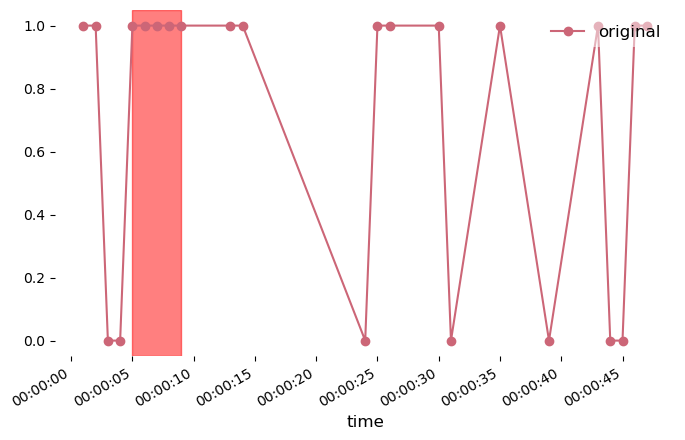

In [334]:
data_array.plot(marker = 'o', label = 'original')
for s, e in zip(start, end):
    # print(s, e)
    plt.axvspan(s.data, e.data, color='red', alpha=0.5)
plt.legend()

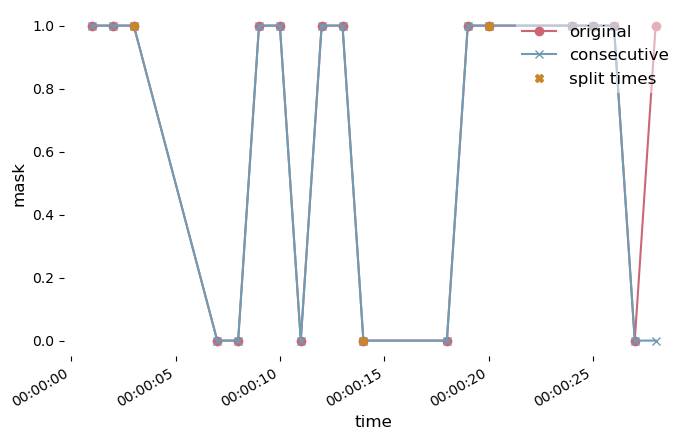

In [147]:
data_array.plot(marker = 'o', label = 'original')
consecutive.plot(marker = 'x', label = 'consecutive')
split_times.plot(marker = 'X', linestyle = 'None', label = 'split times')
plt.legend()

NExt steps would be:
- Compure the diffs to identify start and end times.
- add start and end times accoring to the times array

In [ ]:
diff = consecutive.astype(int).diff(dim = axis)
diff
start_idx = np.where(diff == 1)[0] + 1
end_idx = np.where(diff == -1)[0]
start = dataset['time'].isel({axis : start_idx})
end = dataset['time'].isel({axis : end_idx})

if start.min() > end.min():
    start = xr.concat([dataset[axis][0], start], dim = axis)

if start.max() > end.max():
    end = xr.concat([end, dataset[axis][-1]], dim = axis)

for i in large_diff:
    new_end_idx = i
    new_start_idx = i + 1

    # onlz splt, if for both start and end the mask is True
    if consecutive.isel({axis : new_end_idx}) and consecutive.isel({axis : new_start_idx}):

        start = xr.concat([start, dataset[axis].isel({axis : new_start_idx})], dim = axis)
        end = xr.concat([end, dataset[axis].isel({axis : new_end_idx})], dim = axis)

# validate that all end minus start still is larger than min_duration and remove if not

start = start.sortby(axis)
end = end.sortby(axis)

mask = (end.data - start.data).astype(int) >= min_duration

start = start[mask]
end = end[mask]

In [132]:
start, end

(<xarray.DataArray 'time' (time: 5)>
 array(['2023-01-01T00:00:01.000000000', '2023-01-01T00:00:09.000000000',
        '2023-01-01T00:00:12.000000000', '2023-01-01T00:00:19.000000000',
        '2023-01-01T00:00:24.000000000'], dtype='datetime64[ns]')
 Coordinates:
   * time     (time) datetime64[ns] 2023-01-01T00:00:01 ... 2023-01-01T00:00:24,
 <xarray.DataArray 'time' (time: 5)>
 array(['2023-01-01T00:00:03.000000000', '2023-01-01T00:00:10.000000000',
        '2023-01-01T00:00:13.000000000', '2023-01-01T00:00:20.000000000',
        '2023-01-01T00:00:26.000000000'], dtype='datetime64[ns]')
 Coordinates:
   * time     (time) datetime64[ns] 2023-01-01T00:00:03 ... 2023-01-01T00:00:26)

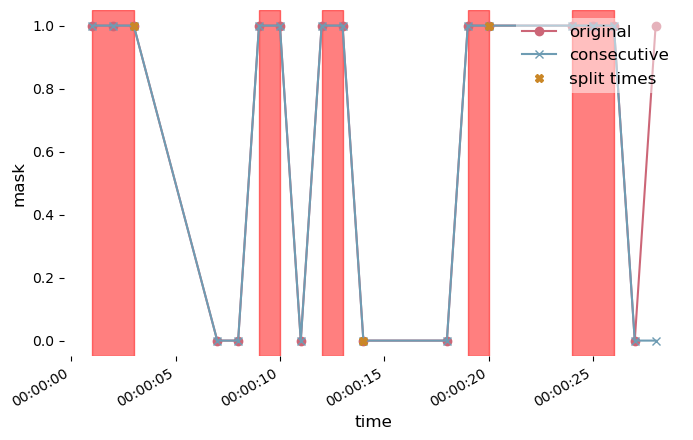

In [133]:
data_array.plot(marker = 'o', label = 'original')
consecutive.plot(marker = 'x', label = 'consecutive')
split_times.plot(marker = 'X', linestyle = 'None', label = 'split times')

for s, e in zip(start, end):
    # print(s, e)
    plt.axvspan(s.data, e.data, color='red', alpha=0.5)
plt.legend()